In [ ]:
print(" Name: Yamini")
print("Roll No: 24BAD131")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import roc_curve, auc, precision_recall_curve
from imblearn.over_sampling import SMOTE

 Name: Yamini
Roll No: 24BAD131


DT Accuracy: 1.0
Bagging Accuracy: 1.0


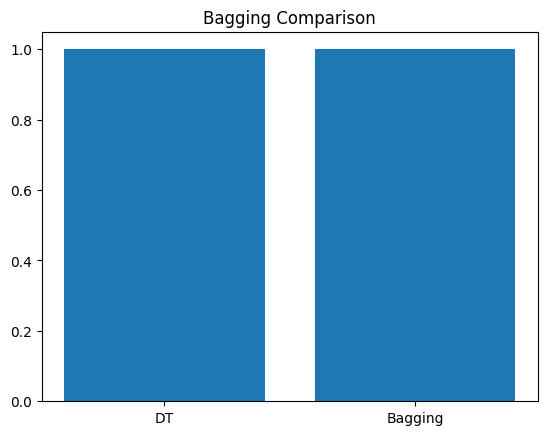

In [ ]:
data = pd.read_csv("diabetes_bagging.csv")

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Bagging
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

# Graph
plt.bar(['DT', 'Bagging'], [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_bag)])
plt.title("Bagging Comparison")
plt.show()

Columns: Index(['Tenure', 'MonthlyCharges', 'ContractType', 'InternetService', 'Churn'], dtype='object')
AdaBoost Accuracy: 1.0
Gradient Boosting Accuracy: 1.0


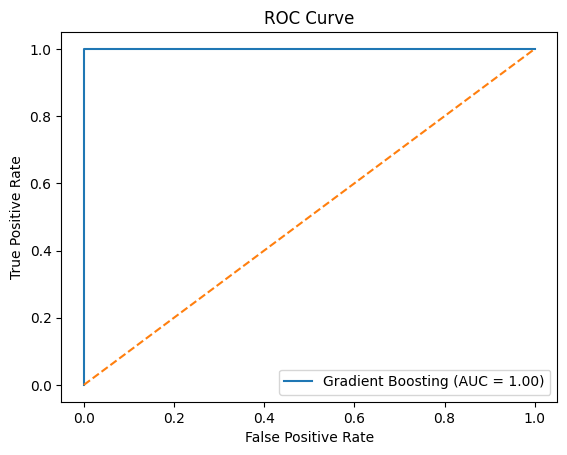

In [ ]:
# Load dataset
data = pd.read_csv("churn_boosting.csv")

# Clean column names
data.columns = data.columns.str.strip()

# Check columns
print("Columns:", data.columns)

# 🔥 Convert target safely (handles Yes/No, 1/0, etc.)
data["Churn"] = data["Churn"].astype(str).str.strip().str.lower()

# Map values
data["Churn"] = data["Churn"].map({
    "yes": 1, "no": 0,
    "1": 1, "0": 0
})

# Drop rows if mapping failed (important)
data = data.dropna(subset=["Churn"])

# Convert categorical features ONLY (exclude target)
X = data.drop("Churn", axis=1)
y = data["Churn"]

X = pd.get_dummies(X, drop_first=True)

# Train-test split (prevents ROC issue)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Models
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

# Train models
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
gb = GradientBoostingClassifier(n_estimators=50, random_state=42)

ada.fit(X_train, y_train)
gb.fit(X_train, y_train)

# Accuracy
print("AdaBoost Accuracy:", accuracy_score(y_test, ada.predict(X_test)))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb.predict(X_test)))

# ROC Curve
y_prob = gb.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Accuracy (10 trees): 1.0
Accuracy (50 trees): 1.0
Accuracy (100 trees): 1.0


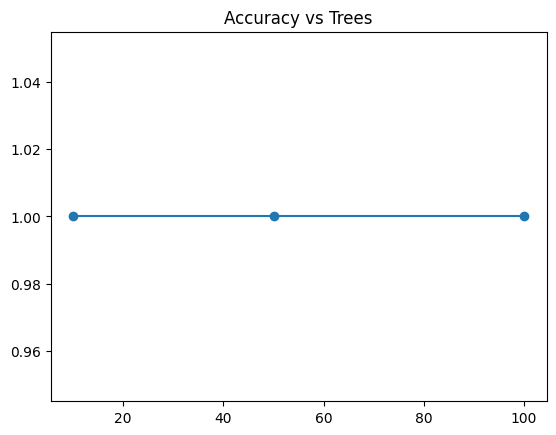

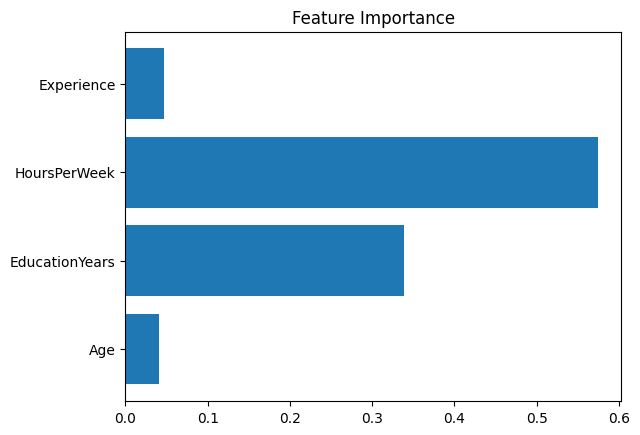

In [ ]:
data = pd.read_csv("income_random_forest.csv")

X = data.drop("Income", axis=1)
y = data["Income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

estimators = [10, 50, 100]
acc_list = []

for n in estimators:
    rf = RandomForestClassifier(n_estimators=n)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    acc_list.append(acc)
    print(f"Accuracy ({n} trees):", acc)

# Graph
plt.plot(estimators, acc_list, marker='o')
plt.title("Accuracy vs Trees")
plt.show()

# Feature Importance
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

plt.barh(X.columns, rf.feature_importances_)
plt.title("Feature Importance")
plt.show()

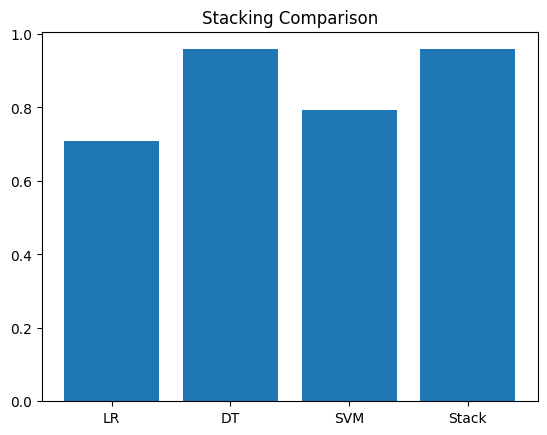

In [ ]:
data = pd.read_csv("heart_stacking.csv")

X = data.drop("HeartDisease", axis=1)
y = data["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Base models
models = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('dt', DecisionTreeClassifier()),
    ('svm', SVC(probability=True))
]

stack = StackingClassifier(estimators=models, final_estimator=LogisticRegression())
stack.fit(X_train, y_train)

# Individual models
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
svm = SVC(probability=True).fit(X_train, y_train)

# Accuracy
acc = [
    accuracy_score(y_test, lr.predict(X_test)),
    accuracy_score(y_test, dt.predict(X_test)),
    accuracy_score(y_test, svm.predict(X_test)),
    accuracy_score(y_test, stack.predict(X_test))
]

plt.bar(['LR','DT','SVM','Stack'], acc)
plt.title("Stacking Comparison")
plt.show()

Before SMOTE:
 Fraud
0    110
1     10
Name: count, dtype: int64

Before SMOTE:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24


After SMOTE:
 Fraud
0    88
1    88
Name: count, dtype: int64

After SMOTE:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.92      0.55      0.69        22
           1       0.09      0.50      0.15         2

    accuracy                           0.54        24
   macro avg       0.51      0.52      0.42        24
weighted avg       0.85      0.54      0.64        24



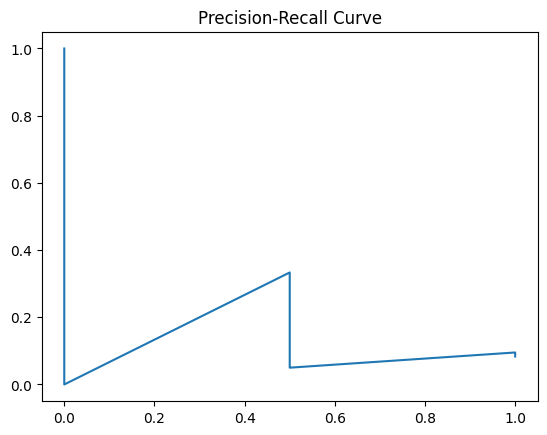

In [ ]:
data = pd.read_csv("fraud_smote.csv")

X = data.drop("Fraud", axis=1)
y = data["Fraud"]

# Before SMOTE
print("Before SMOTE:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model before SMOTE
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nBefore SMOTE:")
print(classification_report(y_test, y_pred))

# Apply SMOTE
smote = SMOTE()
X_res, y_res = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:\n", pd.Series(y_res).value_counts())

# Train again
model.fit(X_res, y_res)
y_pred_smote = model.predict(X_test)

print("\nAfter SMOTE:")
print(classification_report(y_test, y_pred_smote))

# Precision-Recall Curve
y_prob = model.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.show()